In [15]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import sspspace

# autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


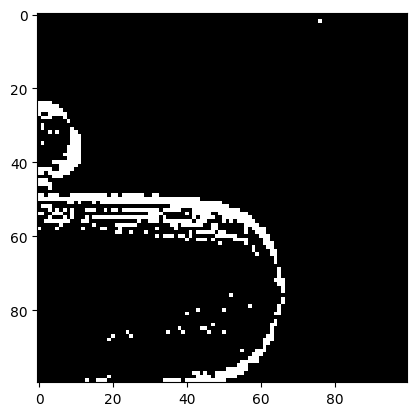

In [16]:
# load and convert to grayscale
img = np.array(Image.open('/home/matt/DATA/CRIB/bboxes/cactus/0/frame_000032_roi.png').convert('L'))
# display image
plt.imshow(img, cmap='gray')

In [17]:
# load coordinates
coordinates = np.load("/home/matt/DATA/CRIB/bboxes/cactus/0/cactus_0_coordinates.npy")
coordinates

array([[123, 149],
       [ 38,  90],
       [ 32,  88],
       [ 26,  89],
       [ 22,  85],
       [ 18,  84],
       [ 14,  86],
       [ 13,  84],
       [ 14,  82],
       [ 11,  85],
       [ 18,  78],
       [268, 176],
       [290, 185],
       [300, 211],
       [306, 200],
       [309, 201],
       [289, 175],
       [256, 159],
       [ 50, 135],
       [251, 153],
       [ 13, 103],
       [ 13, 108],
       [ 16, 112],
       [ 20, 117],
       [267, 147],
       [ 23, 125],
       [261, 140],
       [264, 139],
       [259, 133],
       [263, 130],
       [257, 126],
       [264, 123],
       [318, 150],
       [317, 145],
       [291, 141],
       [ 55, 175],
       [ 59, 180],
       [ 63, 185],
       [ 65, 190],
       [ 70, 194],
       [ 74, 199],
       [ 76, 204],
       [ 82, 207],
       [ 84, 213],
       [ 89, 216],
       [ 94, 219],
       [ 96, 225],
       [ 99, 230],
       [276,  85],
       [107, 238],
       [111, 241],
       [126, 256],
       [129,

In [18]:
from load_model import EmbeddingExtractor
model_path = "./autoencoder/patches_conv/best_model.ckpt"
model = EmbeddingExtractor(model_path=model_path)

Using device: cuda
✅ Model loaded from: ./autoencoder/patches_conv/best_model.ckpt
   Epoch: 19
   Train Loss: 0.011871
   Val Loss: 0.011776
✅ Embedding extractor ready!


[0.02514498 0.02514498 0.02514498 ... 0.01910967 0.01910967 0.01919605]
False
1.0


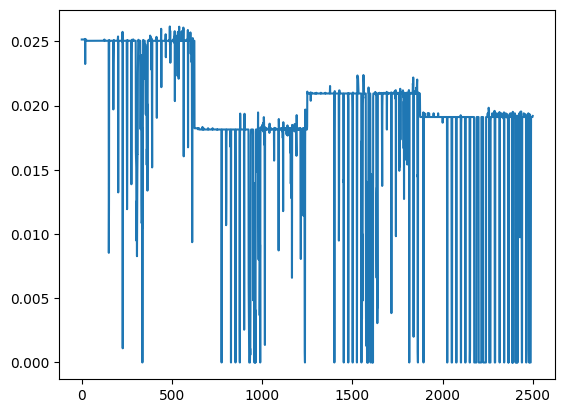

In [19]:
embeddings = model.get_embeddings(img)
print(embeddings)
plt.plot(embeddings)

print(np.any(np.isnan(embeddings)))
print(np.linalg.norm(embeddings))

In [20]:
# Initialize coordinate encoder (same dimensions as Code2CreatingWorkingMemory.py)
coord_encoder = sspspace.RandomSSPSpace(domain_dim=2, ssp_dim=2500)

coordinate = coordinates[32]

# Create spatial encoding from the original attention coordinate
x, y = coordinate
roi_center = coord_encoder.encode([[x, y]])

print("ROI CENTER")
print(roi_center, type(roi_center))

img_feat_ssp = sspspace.SSP(embeddings)

print("IMG FEAT SSP")
print(img_feat_ssp, type(img_feat_ssp))

# Bind coordinate and feature using VSA multiplication
bound_representation = roi_center * img_feat_ssp

print("BOUND REPRESENTATION")
print(bound_representation)

print("ARRAY")
print(np.array(bound_representation))

ROI CENTER
[[-0.01042247  0.02301933  0.02428065 ... -0.02026215 -0.00261595
   0.01835301]] <class 'sspspace.ssp.SSP'>
IMG FEAT SSP
[[0.02514498 0.02514498 0.02514498 ... 0.01910967 0.01910967 0.01919605]] <class 'sspspace.ssp.SSP'>
BOUND REPRESENTATION
[[0.02127839 0.01813353 0.02110374 ... 0.01903799 0.0199126  0.01992207]]
ARRAY
[[0.02127839 0.01813353 0.02110374 ... 0.01903799 0.0199126  0.01992207]]


In [21]:
print(roi_center * roi_center)
roi_center = np.array(roi_center).squeeze()
print(np.linalg.norm(roi_center))
print("Embeddings", type(embeddings), embeddings.shape)
print(np.any(np.isnan(embeddings)))
print(embeddings)
print(np.linalg.norm(embeddings))
print("ROI center", type(roi_center), roi_center.shape)
print(roi_center)
print(roi_center * roi_center)

def bind(a,b):
    a = np.atleast_2d(a)
    b = np.atleast_2d(b)
    return np.fft.ifft(np.fft.fft(a, axis=1) * np.fft.fft(b,axis=1), axis=1).real

bound_representation2 = bind(roi_center, embeddings)
print("BOUND REPRESENTATION2")
print(bound_representation2, type(bound_representation2))

[[ 0.01359399 -0.0188016   0.04438171 ... -0.03797968  0.00908598
   0.01509777]]
1.0
Embeddings <class 'numpy.ndarray'> (2500,)
False
[0.02514498 0.02514498 0.02514498 ... 0.01910967 0.01910967 0.01919605]
1.0
ROI center <class 'numpy.ndarray'> (2500,)
[-0.01042247  0.02301933  0.02428065 ... -0.02026215 -0.00261595
  0.01835301]
[1.08627792e-04 5.29889539e-04 5.89550083e-04 ... 4.10554554e-04
 6.84320413e-06 3.36833106e-04]
BOUND REPRESENTATION2
[[0.02127839 0.01813353 0.02110374 ... 0.01903799 0.0199126  0.01992207]] <class 'numpy.ndarray'>


In [24]:
# load memory vector
bag = np.load('/home/matt/DATA/CRIB/workingmemory_from_bboxes/bag_combined_memory.npy')
binoculars = np.load('/home/matt/DATA/CRIB/workingmemory_from_bboxes/binoculars_combined_memory.npy')
cactus = np.load('/home/matt/DATA/CRIB/workingmemory_from_bboxes/cactus_combined_memory.npy')
dozer = np.load('/home/matt/DATA/CRIB/workingmemory_from_bboxes/dozer_combined_memory.npy')
drill = np.load('/home/matt/DATA/CRIB/workingmemory_from_bboxes/drill_combined_memory.npy')
dumptruck = np.load('/home/matt/DATA/CRIB/workingmemory_from_bboxes/dumptruck_combined_memory.npy')
firetruck = np.load('/home/matt/DATA/CRIB/workingmemory_from_bboxes/firetruck_combined_memory.npy')

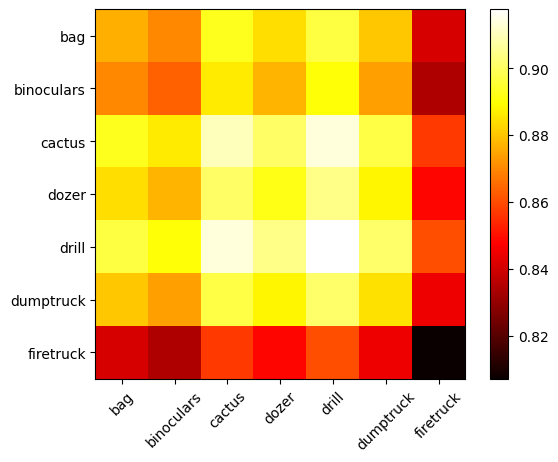

In [30]:
# put objects into array vstack
objects = np.vstack([bag, binoculars, cactus, dozer, drill, dumptruck, firetruck])

sim = objects @ objects.T

plt.imshow(sim, cmap='hot', interpolation='nearest')
# label axes
plt.xticks(ticks=np.arange(7), labels=['bag', 'binoculars', 'cactus', 'dozer', 'drill', 'dumptruck', 'firetruck'], rotation=45)
plt.yticks(ticks=np.arange(7), labels=['bag', 'binoculars', 'cactus', 'dozer', 'drill', 'dumptruck', 'firetruck'])
plt.colorbar()
plt.show()